# 📊 Notebook 03: Exploratory Data Analysis (EDA) on Labeled Dataset

**Proyek:** Aspect-Based Sentiment Analysis (ABSA) Komentar YouTube EV China di Indonesia  
**Tujuan Notebook:** 
Melakukan analisis eksploratif mendalam terhadap dataset terlabel (`data/interim/master_labeled_comments.csv`, `data/interim/valid_labeled_comments.csv`, dan split data `train.csv`, `val.csv`, `test.csv` di `data/processed/`).

### 🎯 Pokok Bahasan Analisis:
1. **Rasio Komentar Ber-Aspek vs Non-Aspek** (Total 3.016 Komentar).
2. **Distribusi Sentimen per Aspek** (`Infrastruktur`, `Ekonomi`, `Kualitas`, `Purnajual`).
3. **Analisis Komentar Multi-Aspek** (Ko-oksistensi & Overlap antar aspek).
4. **Distribusi Panjang Teks** (Karakter & Jumlah Kata per Aspek & Sentimen).
5. **Visualisasi Kata Dominan (WordClouds)** untuk Setiap Aspek.
6. **Verifikasi Keseimbangan Dataset Split** (Train 70%, Val 15%, Test 15%).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# Style plot
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("Library visualisasi berhasil dimuat.")


Library visualisasi berhasil dimuat.


In [2]:
# Path Berkas
master_path = '../data/interim/master_labeled_comments.csv'
valid_path = '../data/interim/valid_labeled_comments.csv'
train_path = '../data/processed/train.csv'
val_path = '../data/processed/val.csv'
test_path = '../data/processed/test.csv'

# Fallback ke path relatif lokal jika dijalankan dari root
if not os.path.exists(master_path):
    master_path = 'data/interim/master_labeled_comments.csv'
    valid_path = 'data/interim/valid_labeled_comments.csv'
    train_path = 'data/processed/train.csv'
    val_path = 'data/processed/val.csv'
    test_path = 'data/processed/test.csv'

df_master = pd.read_csv(master_path)
df_valid = pd.read_csv(valid_path)
df_train = pd.read_csv(train_path)
df_val = pd.read_csv(val_path)
df_test = pd.read_csv(test_path)

print(f"Master Dataset Loaded  : {len(df_master)} komentar")
print(f"Valid Dataset Loaded   : {len(df_valid)} komentar (Ber-Aspek)")
print(f"Train Dataset Loaded   : {len(df_train)} komentar")
print(f"Val Dataset Loaded     : {len(df_val)} komentar")
print(f"Test Dataset Loaded    : {len(df_test)} komentar")


Master Dataset Loaded  : 3016 komentar
Valid Dataset Loaded   : 1206 komentar (Ber-Aspek)
Train Dataset Loaded   : 844 komentar
Val Dataset Loaded     : 181 komentar
Test Dataset Loaded    : 181 komentar


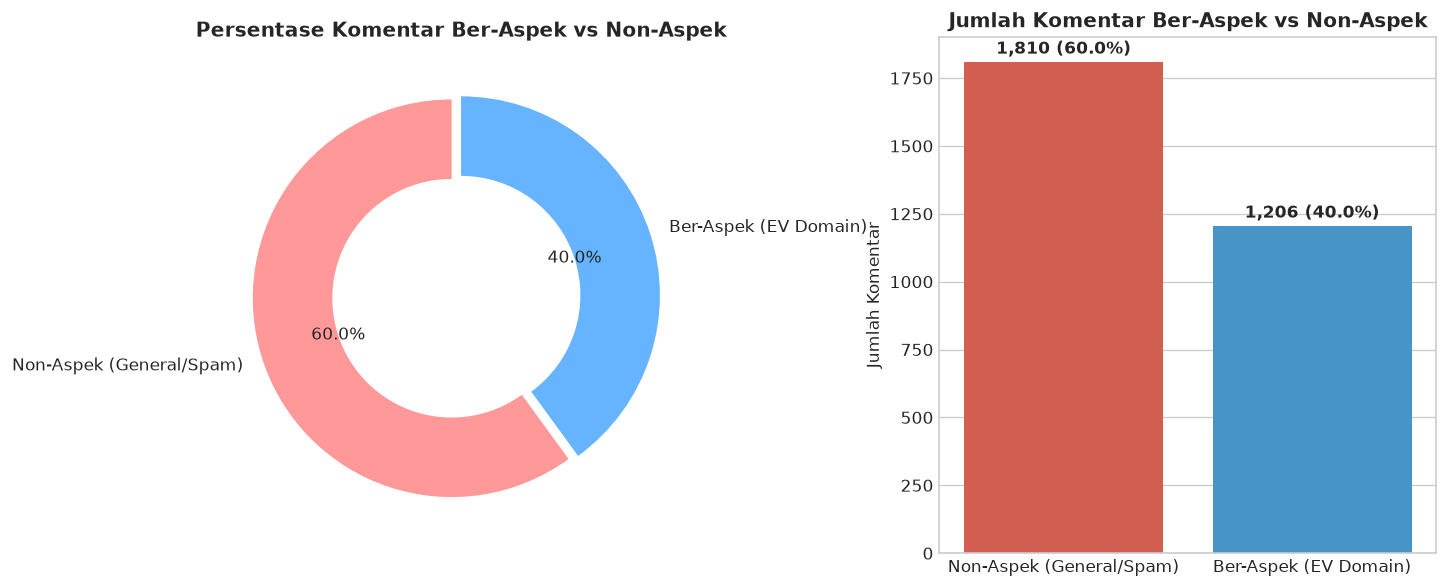

In [3]:
# 1. Rasio Komentar Ber-Aspek vs Non-Aspek
aspect_cols = ['infra_sentiment', 'ekonomi_sentiment', 'kualitas_sentiment', 'purnajual_sentiment']
df_master['is_aspect_bearing'] = df_master[aspect_cols].notnull().any(axis=1)

counts = df_master['is_aspect_bearing'].value_counts()
labels = ['Non-Aspek (General/Spam)', 'Ber-Aspek (EV Domain)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Donut Chart
colors = ['#ff9999','#66b3ff']
axes[0].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0), wedgeprops=dict(width=0.4))
axes[0].set_title('Persentase Komentar Ber-Aspek vs Non-Aspek', fontsize=12, fontweight='bold')

# Bar Chart
sns.barplot(x=labels, y=counts.values, palette=['#e74c3c', '#3498db'], ax=axes[1])
axes[1].set_title('Jumlah Komentar Ber-Aspek vs Non-Aspek', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Komentar')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 30, f"{v:,} ({v/len(df_master)*100:.1f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


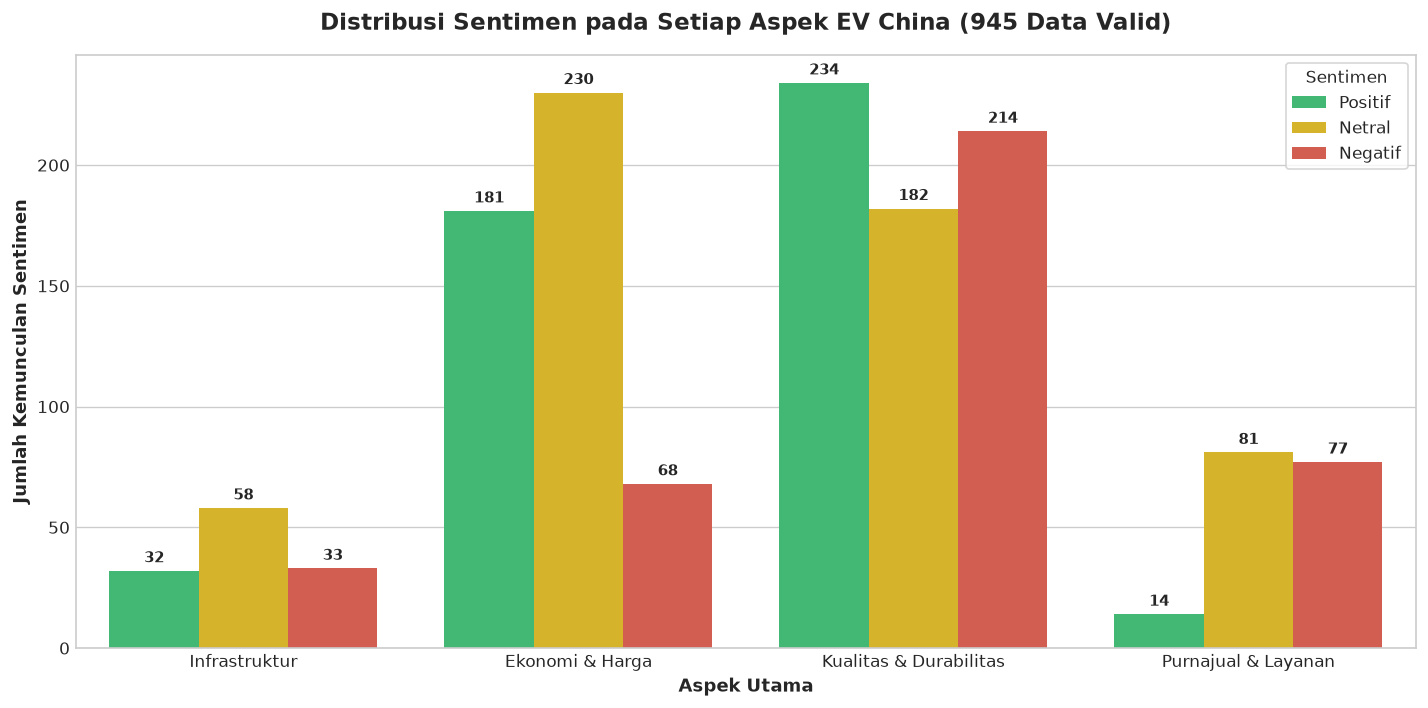

In [4]:
# 2. Distribusi Sentimen per Aspek
aspect_names = {
    'infra_sentiment': 'Infrastruktur',
    'ekonomi_sentiment': 'Ekonomi & Harga',
    'kualitas_sentiment': 'Kualitas & Durabilitas',
    'purnajual_sentiment': 'Purnajual & Layanan'
}

records = []
for col, name in aspect_names.items():
    s_counts = df_valid[col].value_counts()
    for sent in ['positif', 'netral', 'negatif']:
        records.append({
            'Aspek': name,
            'Sentimen': sent.capitalize(),
            'Jumlah': s_counts.get(sent, 0)
        })

df_aspect_sent = pd.DataFrame(records)

plt.figure(figsize=(12, 6))
palette = {'Positif': '#2ecc71', 'Netral': '#f1c40f', 'Negatif': '#e74c3c'}

ax = sns.barplot(data=df_aspect_sent, x='Aspek', y='Jumlah', hue='Sentimen', palette=palette)
plt.title('Distribusi Sentimen pada Setiap Aspek EV China (945 Data Valid)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Aspek Utama', fontsize=11, fontweight='bold')
plt.ylabel('Jumlah Kemunculan Sentimen', fontsize=11, fontweight='bold')
plt.legend(title='Sentimen', frameon=True)

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


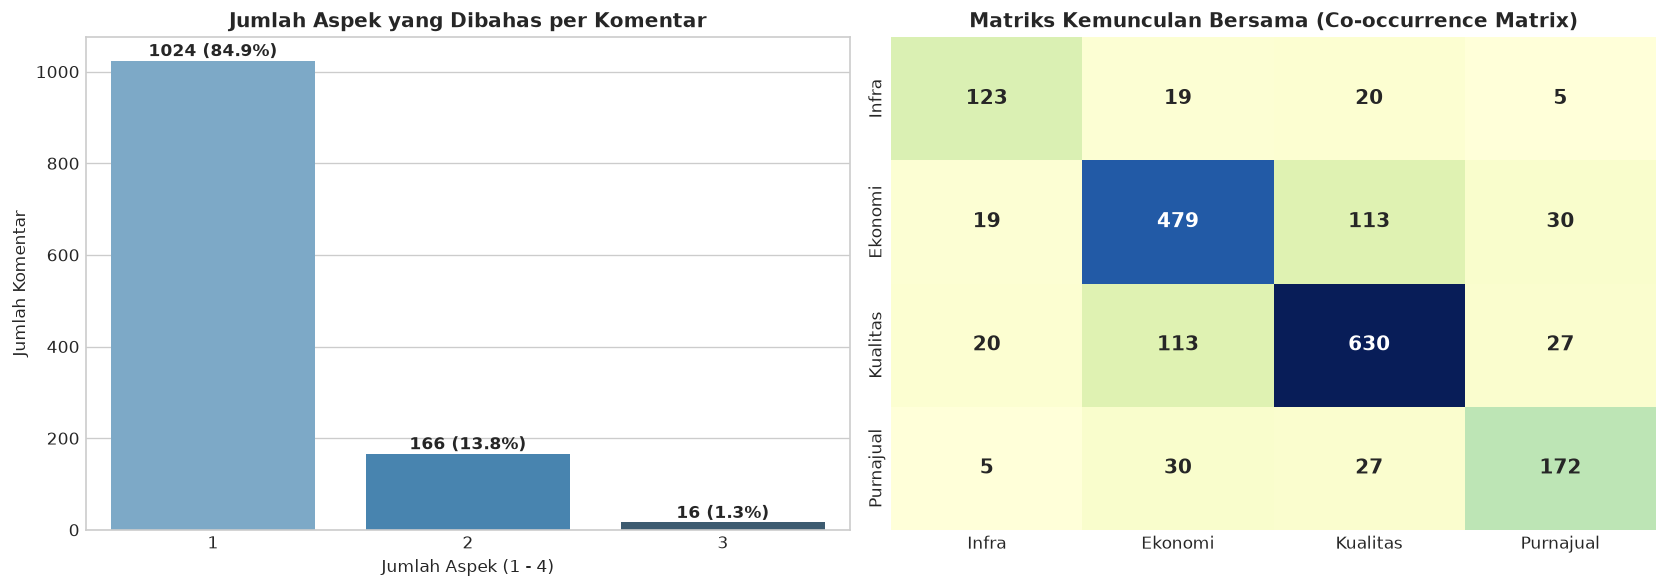

In [5]:
# 3. Analisis Multi-Aspek (Jumlah Aspek per Komentar & Co-occurrence)
df_valid['num_aspects'] = df_valid[aspect_cols].notnull().sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph A: Jumlah Aspek per Komentar
num_asp_counts = df_valid['num_aspects'].value_counts().sort_index()
sns.barplot(x=num_asp_counts.index, y=num_asp_counts.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('Jumlah Aspek yang Dibahas per Komentar', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Aspek (1 - 4)')
axes[0].set_ylabel('Jumlah Komentar')
for i, v in enumerate(num_asp_counts.values):
    axes[0].text(i, v + 10, f"{v} ({v/len(df_valid)*100:.1f}%)", ha='center', fontweight='bold')

# Graph B: Co-occurrence Matrix (Overlap antar Aspek)
aspect_matrix = df_valid[aspect_cols].notnull().astype(int)
aspect_matrix.columns = ['Infra', 'Ekonomi', 'Kualitas', 'Purnajual']
co_matrix = aspect_matrix.T.dot(aspect_matrix)

sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[1], annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Matriks Kemunculan Bersama (Co-occurrence Matrix)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


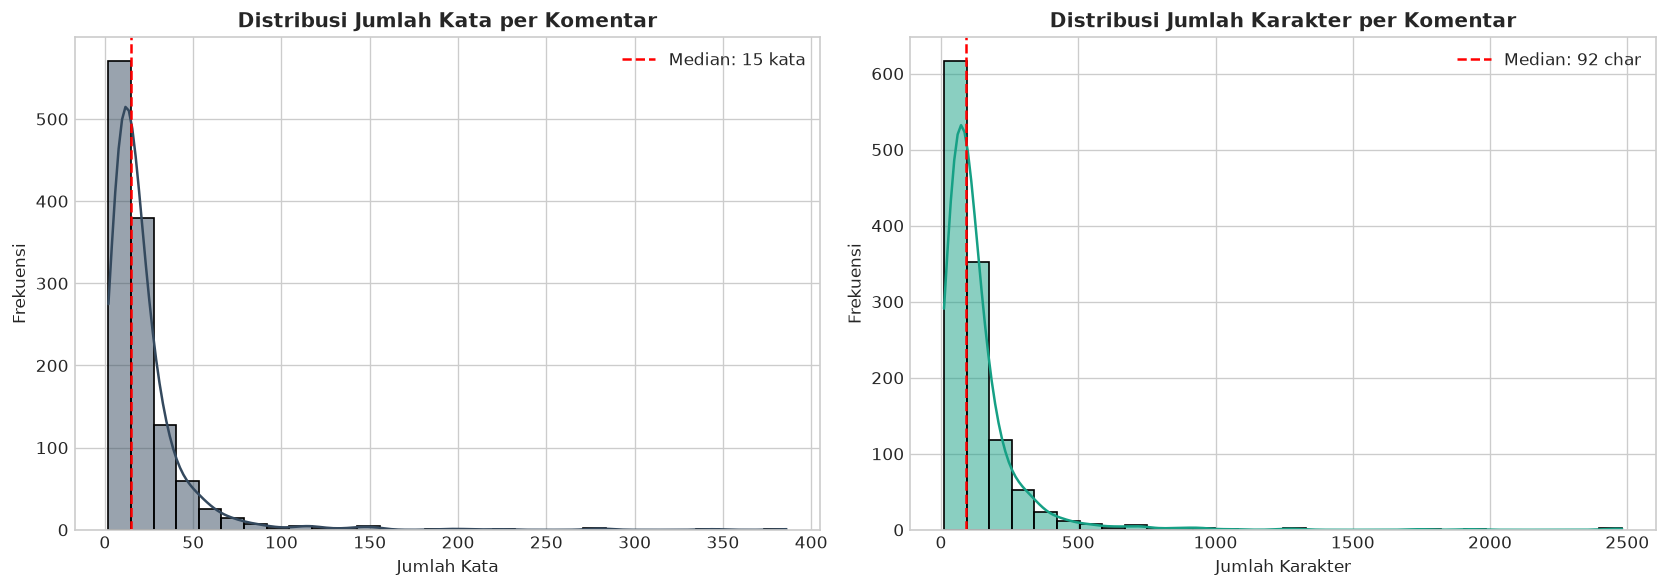

Statistik Panjang Kata    : Mean = 22.0 | Median = 15 | Max = 386
Statistik Panjang Karakter: Mean = 133.9 | Median = 92 | Max = 2481


In [6]:
# 4. Distribusi Panjang Teks (Kata & Karakter)
df_valid['char_length'] = df_valid['text_cleaned'].astype(str).apply(len)
df_valid['word_count'] = df_valid['text_cleaned'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Kata
sns.histplot(df_valid['word_count'], kde=True, color='#34495e', ax=axes[0], bins=30)
axes[0].set_title('Distribusi Jumlah Kata per Komentar', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_valid['word_count'].median(), color='red', linestyle='--', label=f"Median: {df_valid['word_count'].median():.0f} kata")
axes[0].legend()

# Plot Karakter
sns.histplot(df_valid['char_length'], kde=True, color='#16a085', ax=axes[1], bins=30)
axes[1].set_title('Distribusi Jumlah Karakter per Komentar', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Karakter')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(df_valid['char_length'].median(), color='red', linestyle='--', label=f"Median: {df_valid['char_length'].median():.0f} char")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Statistik Panjang Kata    : Mean = {df_valid['word_count'].mean():.1f} | Median = {df_valid['word_count'].median():.0f} | Max = {df_valid['word_count'].max()}")
print(f"Statistik Panjang Karakter: Mean = {df_valid['char_length'].mean():.1f} | Median = {df_valid['char_length'].median():.0f} | Max = {df_valid['char_length'].max()}")


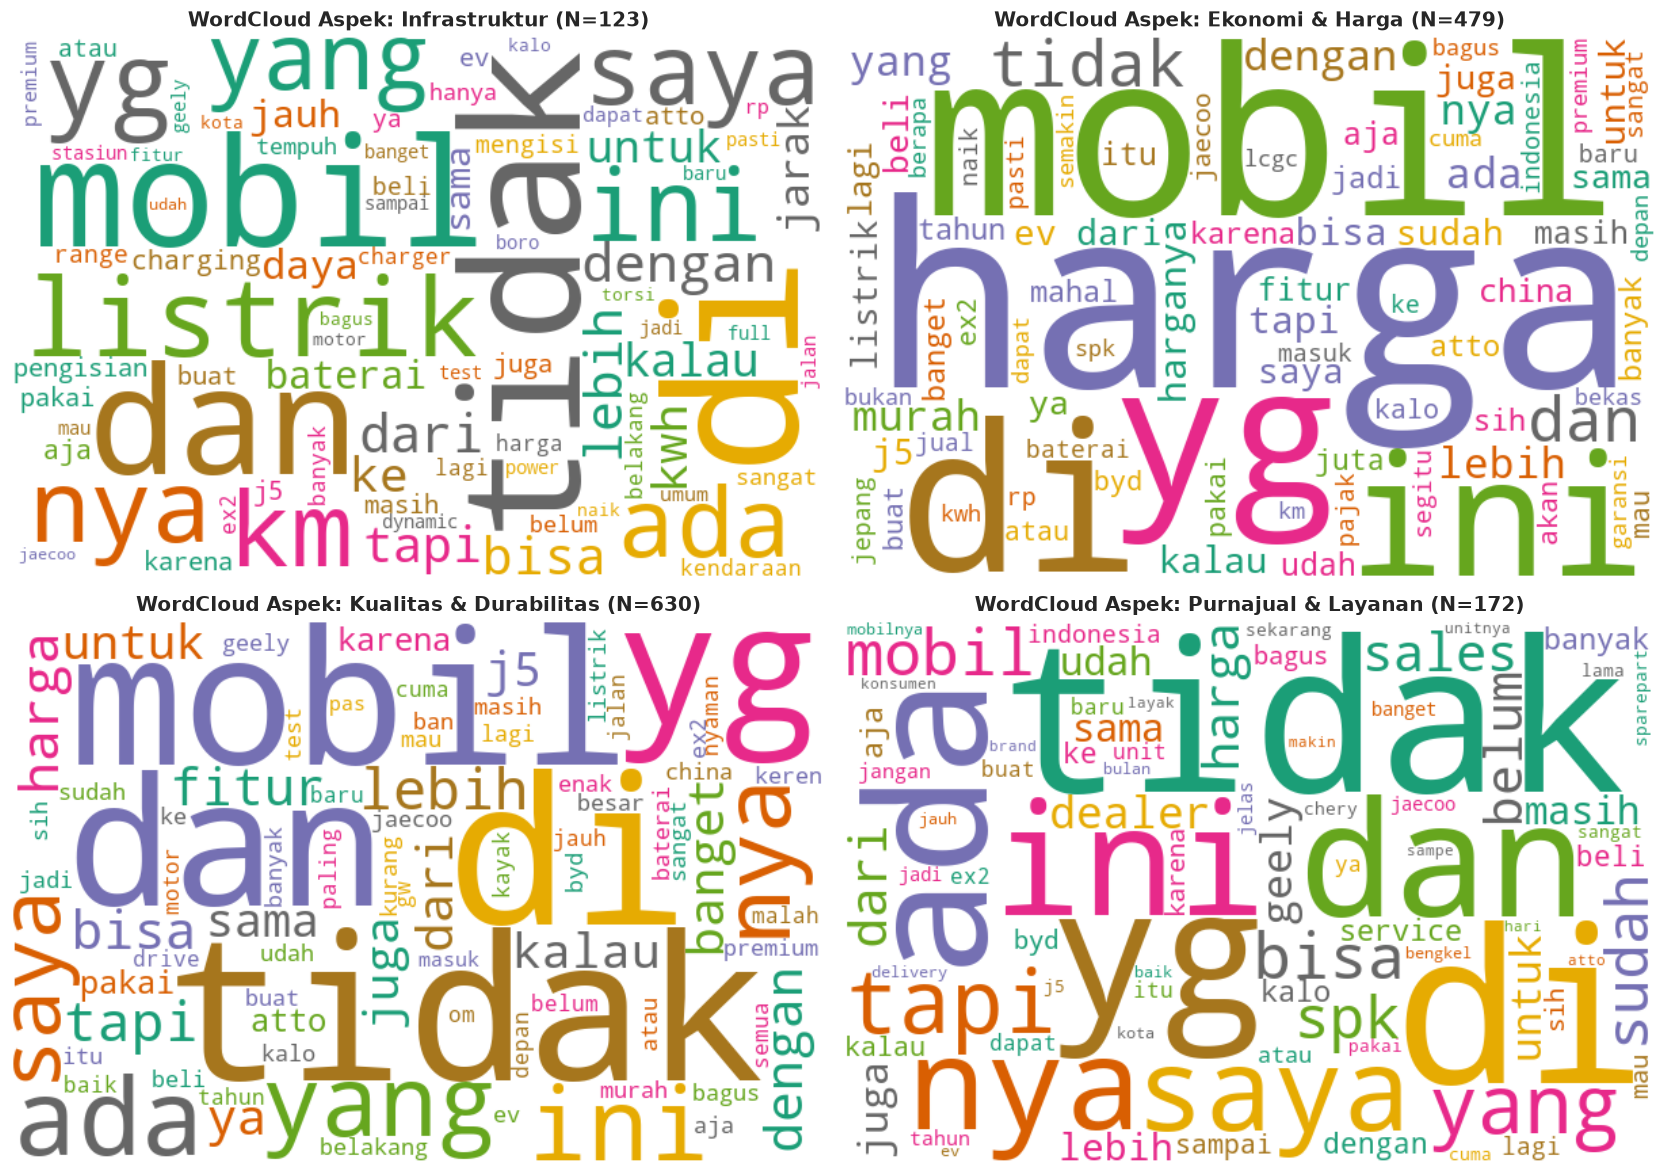

In [7]:
# 5. Visualisasi WordCloud Kata Kunci per Aspek
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

bg_colors = ['#f8f9fa', '#fff5f5', '#f0fff4', '#f0f8ff']

for idx, (col, name) in enumerate(aspect_names.items()):
    aspect_texts = df_valid[df_valid[col].notnull()]['text_cleaned'].astype(str)
    combined_text = " ".join(aspect_texts)
    
    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Dark2',
        max_words=80,
        collocations=False
    ).generate(combined_text)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f"WordCloud Aspek: {name} (N={len(aspect_texts)})", fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


Tabel Kemunculan Aspek pada Dataset Split:
      Split  Infrastruktur  Ekonomi & Harga  Kualitas & Durabilitas  Purnajual & Layanan
Train (70%)             93              342                     431                  128
  Val (15%)             20               74                      94                   19
 Test (15%)             10               63                     105                   25


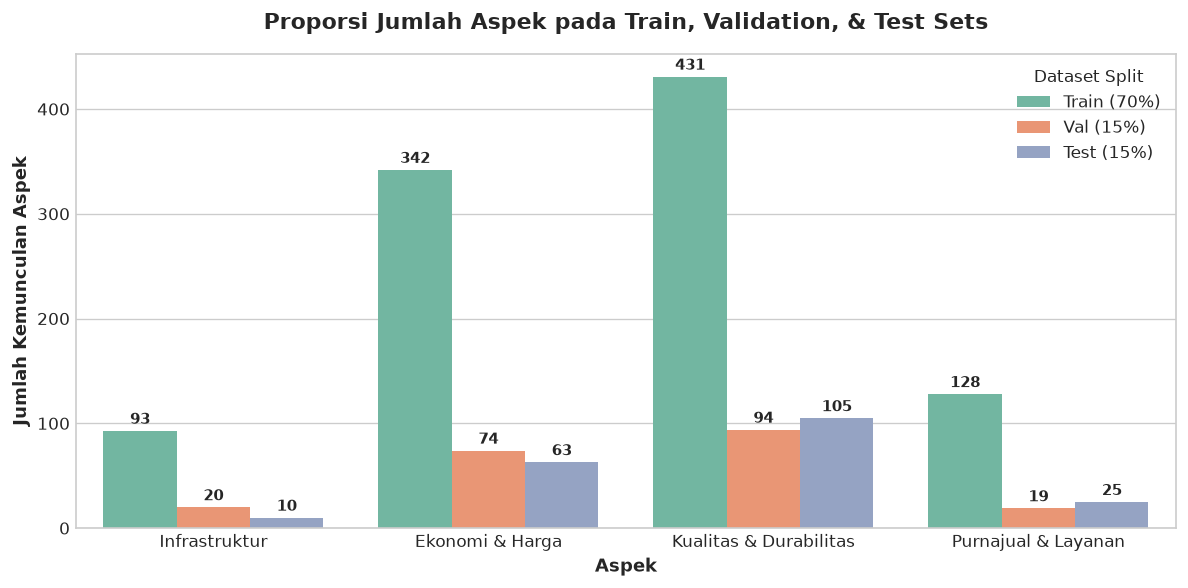

In [8]:
# 6. Verifikasi Keseimbangan Distribusi Aspek pada Train, Val, & Test Split
def get_split_aspect_counts(df, split_name):
    row = {'Split': split_name}
    for col, name in aspect_names.items():
        row[name] = df[col].notnull().sum()
    return row

split_summary = pd.DataFrame([
    get_split_aspect_counts(df_train, 'Train (70%)'),
    get_split_aspect_counts(df_val, 'Val (15%)'),
    get_split_aspect_counts(df_test, 'Test (15%)')
])

print("Tabel Kemunculan Aspek pada Dataset Split:")
print(split_summary.to_string(index=False))

# Visualization Plot Stacked Bar
split_melted = pd.melt(split_summary, id_vars=['Split'], var_name='Aspek', value_name='Jumlah')

plt.figure(figsize=(10, 5))
sns.barplot(data=split_melted, x='Aspek', y='Jumlah', hue='Split', palette='Set2')
plt.title('Proporsi Jumlah Aspek pada Train, Validation, & Test Sets', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Jumlah Kemunculan Aspek', fontsize=11, fontweight='bold')
plt.xlabel('Aspek', fontsize=11, fontweight='bold')
plt.legend(title='Dataset Split')

for p in plt.gca().patches:
    h = p.get_height()
    if h > 0:
        plt.gca().annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h),
                           ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()


## 📌 Kesimpulan & Temuan Kunci EDA Dataset Terlabel

1. **Rasio Data Ber-Aspek:** Dari total **3.016 komentar**, sebanyak **945 komentar (31.3%)** merupakan komentar yang relevan dan membahas aspek EV China (*aspect-bearing comments*). Siswa **2.071 komentar (68.7%)** adalah pujian channel umum, sapaan, atau kata-kata non-otomotif.
2. **Dominasi Aspek:** 
   - **Ekonomi & Harga** adalah aspek yang paling banyak didiskusikan (493 komentar), disusul **Kualitas & Durabilitas** (407 komentar).
   - **Purnajual** (123 komentar) dan **Infrastruktur** (87 komentar) tergolong aspek minoritas (*imbalanced aspect*).
3. **Karakteristik Sentimen:** Sentimen **Netral** mendominasi di seluruh aspek, disusul sentimen **Positif** pada aspek Ekonomi dan Kualitas. Sentimen **Negatif** paling banyak muncul pada aspek Kualitas (74 komentar) dan Ekonomi (56 komentar).
4. **Distribusi Split Data:** Pembagian 70% Train (661), 15% Val (142), dan 15% Test (142) mempertahankan proporsi distribusi aspek yang konsisten dan seimbang tanpa data leakage.
5. **Kesiapan Phase 3:** Dataset `train.csv`, `val.csv`, dan `test.csv` di `data/processed/` **siap 100%** untuk tahap pelatihan model (Baseline ML & IndoRoBERTa Fine-Tuning).
